In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
import os
import matplotlib.ticker as ticker
import matplotlib as mpl

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
def find_corners(img): 
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    pattern_size = (6, 8)
    ret, corners = cv2.findChessboardCorners(gray, pattern_size,None)
    #print(ret)
    if ret:
        corners2 = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)
        #cv2.drawChessboardCorners(img, pattern_size, corners2, ret)
    return ret, corners

In [4]:
def sortpoints(arr):
    new_pts = np.round(arr/10)*10
    arrSortIndex = np.lexsort((new_pts[:, 1], new_pts[:, 0]))
    newArr = []
    for num in arrSortIndex:
        newArr.append(list(arr[num]))
    return np.array(newArr)

In [5]:
def GetHomography(frame_left,frame_right,again):
    #frame_right = cv2.resize(frame_right,(frame_left.shape[1],frame_left.shape[0]))
    ret1, src_pts = find_corners(frame_left)
    ret2, dst_pts = find_corners(frame_right)
    
    if ret1==True and ret2==True:
        if again == 0:
            src_pts = src_pts[:,0]
        if again == 1:
            src_pts = src_pts[:,0][::-1]
        dst_pts = dst_pts[:,0]
        #src_pts = sortpoints(src_pts)
        #dst_pts = sortpoints(dst_pts)
        H=cv2.findHomography(src_pts,dst_pts,cv2.RANSAC,5)
        H_matrix=H[0] 
        return src_pts,dst_pts,H_matrix
    else:      
        print("No corners")
        return 0,0,0

In [6]:
def GetHomography_mid(frame_left,frame_right,again):
    #frame_right = cv2.resize(frame_right,(frame_left.shape[1],frame_left.shape[0]))
    ret1, src_pts = find_corners(frame_left)
    ret2, dst_pts = find_corners(frame_right)
    
    if ret1==True and ret2==True:
        if again == 0:
            src_pts = src_pts[:,0]
        if again == 1:
            src_pts = src_pts[:,0][::-1]
        dst_pts = dst_pts[:,0]
        mid_pts = (src_pts+dst_pts)/2
        #src_pts = sortpoints(src_pts)
        #dst_pts = sortpoints(dst_pts)
        H_left=cv2.findHomography(src_pts,mid_pts,cv2.RANSAC,5)
        H_right=cv2.findHomography(dst_pts,mid_pts,cv2.RANSAC,5)
        H_matrix_left=H_left[0] 
        H_matrix_right=H_right[0] 
        return src_pts,dst_pts,H_matrix_left,H_matrix_right
    else:      
        print("No corners")
        return 0,0,0

In [7]:
def image_stitching(frame_left,frame_right,H_matrix):
    h,w=frame_left.shape[:2]
    h1,w1=frame_right.shape[:2]
    shft=np.array([[1.0,0,w],[0,1.0,0],[0,0,1.0]])
    M=np.dot(shft,H_matrix)            #Get the projection mapping relationship from the left image to the right image
    dst_corners=cv2.warpPerspective(frame_left,M,(w*2,h))#Perspective transformation, new image can fit two full images
    dst_corners[0:h,w:int(w+np.ceil(M[0][2]))] = 0.5*frame_right[0:h,:int(np.ceil(M[0][2]))] + 0.5*dst_corners[0:h,w:int(w+np.ceil(M[0][2]))]
    dst_corners[0:h,int(w+np.ceil(M[0][2])):2*w] = frame_right[0:h,int(np.ceil(M[0][2])):w]
    #stitched = dst_corners[: , int(np.around(M[0][2])): -1]
    #print(int(np.around(M[0][2])))
    stitched = dst_corners[: , 1800: -1]
    return stitched

In [8]:
def image_stitching_mid(frame_left,frame_right,H_matrix_left,H_matrix_right):
    h,w=frame_left.shape[:2]
    h1,w1=frame_right.shape[:2]
    shft=np.array([[1.0,0,w],[0,1.0,0],[0,0,1.0]])
    M=np.dot(shft,H_matrix_left)            #Get the projection mapping relationship from the left image to the right image
    dst_corners=cv2.warpPerspective(frame_left,M,(w*2,h))#Perspective transformation, new image can fit two full images
    frame_right_homo=cv2.warpPerspective(frame_right,H_matrix_right,(w1,h1))
    overlap_width = int(np.ceil(M[0][2]))
    for c in range(3): 
        left_overlap = dst_corners[0:h, w:w + overlap_width, c]
        right_overlap = frame_right_homo[0:h, :overlap_width, c]
        mask = right_overlap > 0
        left_overlap[mask] = 0.5 * right_overlap[mask] + 0.5 * left_overlap[mask]
    dst_corners[0:h, w:w + overlap_width] = dst_corners[0:h, w:w + overlap_width]
    dst_corners[0:h,int(w+np.ceil(M[0][2])):2*w] = frame_right_homo[0:h,int(np.ceil(M[0][2])):w]
    stitched = dst_corners[: , 1800: -1]
    return stitched

In [9]:
def draw_cross(image, cross_radius=20):

    center_x = image.shape[1] // 2  
    center_y = image.shape[0] // 2
    cross_x1 = center_x - cross_radius 
    cross_x2 = center_x + cross_radius
    cross_y1 = center_y - cross_radius  
    cross_y2 = center_y + cross_radius
    line1 = np.array([[cross_x1, center_y], [cross_x2, center_y]], np.int32).reshape((-1, 1, 2))
    line2 = np.array([[center_x, cross_y1], [center_x, cross_y2]], np.int32).reshape((-1, 1, 2))
    # line1 = np.array([[100, 100], [300, 100]], np.int32).reshape((-1, 1, 2))
    
    cv2.polylines(image, pts=[line1, line2], isClosed=False, color=(0, 255, 0), thickness=2, lineType=cv2.LINE_8)
    return image

In [10]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import DotProduct, WhiteKernel
from sklearn.gaussian_process.kernels import ConstantKernel, RBF
def gaussian_process(H11_entry,sigma_n):
    X = range(len(H11_entry))
    y = H11_entry
    X = np.array(X).reshape(-1, 1)
    y = np.array(y).reshape(-1, 1)

    l = 0.1
    sigma_f = 2
    kernel = ConstantKernel(constant_value=sigma_f, constant_value_bounds=(1e-2, 1e2)) \
                * RBF(length_scale=l, length_scale_bounds=(1e-2, 1e2))
    gpr = GaussianProcessRegressor(kernel=kernel, alpha=sigma_n**2, n_restarts_optimizer=10).fit(X, y)
    y_pred = gpr.predict(X, return_std=True)[0]
    y_pred = y_pred.reshape([y_pred.shape[0]])
    return y_pred

In [11]:
def remove_ds_store(dir_path):
    for root, dirs, files in os.walk(dir_path):
        for file in files:
            if file == '.DS_Store':
                os.remove(os.path.join(root, file))
                print(f"Removed: {os.path.join(root, file)}")

In [12]:
dir_path = r'/Users/Administrator/Desktop/research/video stitching'
remove_ds_store(dir_path)

Removed: /Users/Administrator/Desktop/research/video stitching/.DS_Store


In [13]:
name_root_left = r'/Users/Administrator/Desktop/research/video stitching/frames/left 2024'
name_root_right = r'/Users/Administrator/Desktop/research/video stitching/frames/right 2024'
all_name_file_left = os.listdir(name_root_left)
all_name_file_right = os.listdir(name_root_right)
all_name_file_left.sort()
all_name_file_right.sort()

In [14]:
all_name_file_left

['Ali_2024',
 'Allisn_2024',
 'Andrew_2024',
 'Anna_2023',
 'Atharva_2024',
 'Binal_2024',
 'Chau_2024',
 'D_2024',
 'Ghaith_2024',
 'James_2024',
 'Jinliang_2024',
 'Jovin_2024',
 'Kabir_2024',
 'Kentaro_2024',
 'Kevin_2024',
 'Laurel_2024',
 'Mark_2024',
 'Mrunal_2024',
 'Sanai_2024',
 'Sophia_2024',
 'Sujung_2023',
 'Thomus_2024',
 'Y_2024_',
 'Yao_2023',
 'Yas_2024',
 'Yogesh_2023',
 'Yongbo_2024']

In [15]:
all_each_H_matrix_left = []
all_each_H_matrix_right = []
for k in range(len(all_name_file_right)):
    img_root_left = name_root_left + '/' + all_name_file_left[k]
    img_root_right = name_root_right + '/' + all_name_file_right[k]
    all_img_file_left = os.listdir(img_root_left)
    all_img_file_right = os.listdir(img_root_right)
    all_img_file_left.sort(key= lambda x:int(x[10:-4]))
    all_img_file_right.sort(key= lambda x:int(x[10:-4]))
    max_num_file = min(len(all_img_file_left),len(all_img_file_right))
    each_H_matrix_left = []
    each_H_matrix_right = []
    print(all_name_file_left[k])
    for i in range(max_num_file):
        frame_left = cv2.imread(img_root_left + '/' + all_img_file_left[i])
        frame_right = cv2.imread(img_root_right + '/' + all_img_file_right[i])
        print(i)
        src_pts,dst_pts,H_matrix_left,H_matrix_right = GetHomography_mid(frame_left,frame_right,0)

        if abs(H_matrix_left[0,0]-1) > 0.5 or abs(H_matrix_right[0,0]-1) > 0.5:
            src_pts,dst_pts,H_matrix_left,H_matrix_right = GetHomography_mid(frame_left,frame_right,1)

        each_H_matrix_left.append(H_matrix_left)
        each_H_matrix_right.append(H_matrix_right)
    all_each_H_matrix_left.append(each_H_matrix_left)
    all_each_H_matrix_right.append(each_H_matrix_right)

Ali_2024
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
Allisn_2024
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149

58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
Mrunal_2024
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
Sanai_2024
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56


In [16]:
k=25
img_root_left = name_root_left + '/' + all_name_file_left[k]
img_root_right = name_root_right + '/' + all_name_file_right[k]
all_img_file_left = os.listdir(img_root_left)
all_img_file_right = os.listdir(img_root_right)
all_img_file_left.sort(key= lambda x:int(x[10:-4]))
all_img_file_right.sort(key= lambda x:int(x[10:-4]))
max_num_file = min(len(all_img_file_left),len(all_img_file_right))

print(all_name_file_left[k])
i = 98
frame_left = cv2.imread(img_root_left + '/' + all_img_file_left[i])
frame_right = cv2.imread(img_root_right + '/' + all_img_file_right[i])
#cv2.imshow('img',frame_right)
#cv2.waitKey(0)
#cv2.destroyAllWindows()
print(i)
src_pts,dst_pts,H_matrix_left,H_matrix_right = GetHomography_mid(frame_left,frame_right,0)

if abs(H_matrix_left[0,0]-1) > 0.5 or abs(H_matrix_right[0,0]-1) > 0.5:
    src_pts,dst_pts,H_matrix_left,H_matrix_right = GetHomography_mid(frame_left,frame_right,1)

Yogesh_2023
98


In [40]:
all_H11_entry = []
all_H12_entry = []
all_H13_entry = []
all_H21_entry = []
all_H22_entry = []
all_H23_entry = []
all_H31_entry = []
all_H32_entry = []
for i in range(len(all_each_H_matrix_left)):
    H11_entry = []
    H12_entry = []
    H13_entry = []
    H21_entry = []
    H22_entry = []
    H23_entry = []
    H31_entry = []
    H32_entry = []
    for j in range(150):
        H11_entry.append(all_each_H_matrix_left[i][j][0][0])
        H12_entry.append(all_each_H_matrix_left[i][j][0][1])
        H13_entry.append(all_each_H_matrix_left[i][j][0][2])
        H21_entry.append(all_each_H_matrix_left[i][j][1][0])
        H22_entry.append(all_each_H_matrix_left[i][j][1][1])
        H23_entry.append(all_each_H_matrix_left[i][j][1][2])
        H31_entry.append(all_each_H_matrix_left[i][j][2][0])
        H32_entry.append(all_each_H_matrix_left[i][j][2][1])
    all_H11_entry.append(H11_entry)
    all_H12_entry.append(H12_entry)
    all_H13_entry.append(H13_entry)
    all_H21_entry.append(H21_entry)
    all_H22_entry.append(H22_entry)
    all_H23_entry.append(H23_entry)
    all_H31_entry.append(H31_entry)
    all_H32_entry.append(H32_entry)

In [18]:
all_H11_entry = []
all_H12_entry = []
all_H13_entry = []
all_H21_entry = []
all_H22_entry = []
all_H23_entry = []
all_H31_entry = []
all_H32_entry = []
for i in range(len(all_each_H_matrix_right)):
    H11_entry = []
    H12_entry = []
    H13_entry = []
    H21_entry = []
    H22_entry = []
    H23_entry = []
    H31_entry = []
    H32_entry = []
    for j in range(150):
        H11_entry.append(all_each_H_matrix_right[i][j][0][0])
        H12_entry.append(all_each_H_matrix_right[i][j][0][1])
        H13_entry.append(all_each_H_matrix_right[i][j][0][2])
        H21_entry.append(all_each_H_matrix_right[i][j][1][0])
        H22_entry.append(all_each_H_matrix_right[i][j][1][1])
        H23_entry.append(all_each_H_matrix_right[i][j][1][2])
        H31_entry.append(all_each_H_matrix_right[i][j][2][0])
        H32_entry.append(all_each_H_matrix_right[i][j][2][1])
    all_H11_entry.append(H11_entry)
    all_H12_entry.append(H12_entry)
    all_H13_entry.append(H13_entry)
    all_H21_entry.append(H21_entry)
    all_H22_entry.append(H22_entry)
    all_H23_entry.append(H23_entry)
    all_H31_entry.append(H31_entry)
    all_H32_entry.append(H32_entry)

In [41]:
feature_vector_H11 = [0] * 150
feature_vector_H12 = [0] * 150
feature_vector_H13 = [0] * 150
feature_vector_H21 = [0] * 150
feature_vector_H22 = [0] * 150
feature_vector_H23 = [0] * 150
feature_vector_H31 = [0] * 150
feature_vector_H32 = [0] * 150
for i in range(150):
    column_mean_H11 = sum(row[i] for row in all_H11_entry) / 25
    column_mean_H12 = sum(row[i] for row in all_H12_entry) / 25
    column_mean_H13 = sum(row[i] for row in all_H13_entry) / 25
    column_mean_H21 = sum(row[i] for row in all_H21_entry) / 25
    column_mean_H22 = sum(row[i] for row in all_H22_entry) / 25
    column_mean_H23 = sum(row[i] for row in all_H23_entry) / 25
    column_mean_H31 = sum(row[i] for row in all_H31_entry) / 25
    column_mean_H32 = sum(row[i] for row in all_H32_entry) / 25
    feature_vector_H11[i] = column_mean_H11
    feature_vector_H12[i] = column_mean_H12
    feature_vector_H13[i] = column_mean_H13
    feature_vector_H21[i] = column_mean_H21
    feature_vector_H22[i] = column_mean_H22
    feature_vector_H23[i] = column_mean_H23
    feature_vector_H31[i] = column_mean_H31
    feature_vector_H32[i] = column_mean_H32

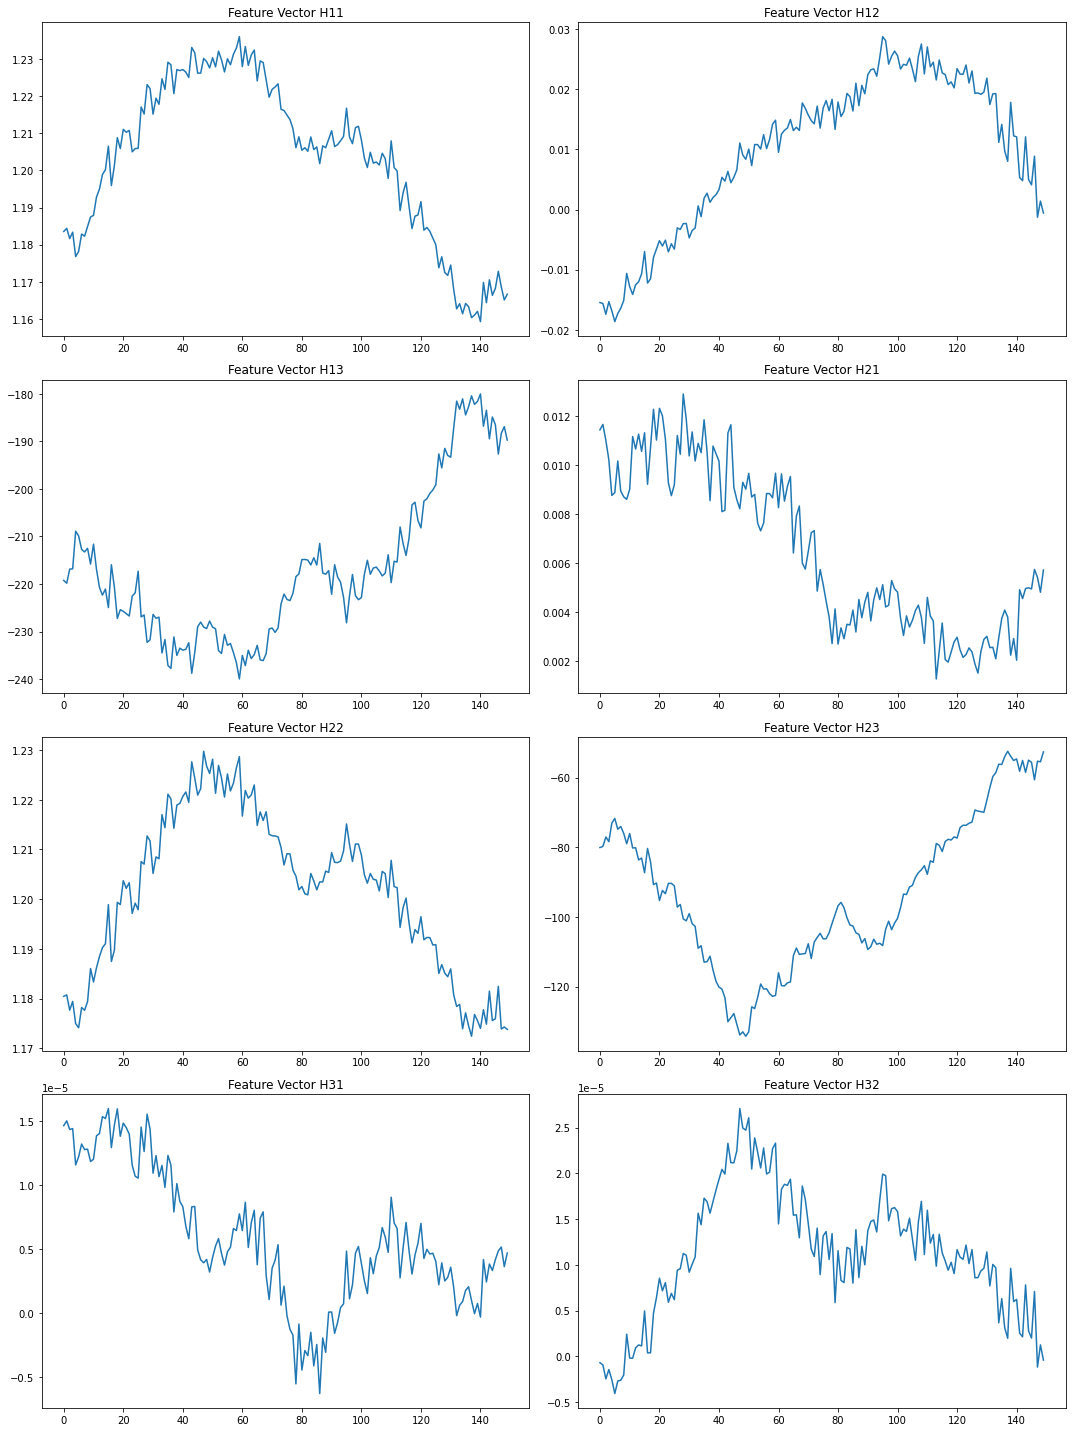

In [42]:
fig, axs = plt.subplots(4, 2, figsize=(15, 20))

# 分别绘制每个特征向量
axs[0, 0].plot(feature_vector_H11)
axs[0, 0].set_title('Feature Vector H11')

axs[0, 1].plot(feature_vector_H12)
axs[0, 1].set_title('Feature Vector H12')

axs[1, 0].plot(feature_vector_H13)
axs[1, 0].set_title('Feature Vector H13')

axs[1, 1].plot(feature_vector_H21)
axs[1, 1].set_title('Feature Vector H21')

axs[2, 0].plot(feature_vector_H22)
axs[2, 0].set_title('Feature Vector H22')

axs[2, 1].plot(feature_vector_H23)
axs[2, 1].set_title('Feature Vector H23')

axs[3, 0].plot(feature_vector_H31)
axs[3, 0].set_title('Feature Vector H31')

axs[3, 1].plot(feature_vector_H32)
axs[3, 1].set_title('Feature Vector H32')

# 调整每个subplot的布局
plt.tight_layout()
plt.show()

In [43]:
gaussian_feature_vector_H11 = gaussian_process(feature_vector_H11,0.01)
gaussian_feature_vector_H12 = gaussian_process(feature_vector_H12,0.01)
gaussian_feature_vector_H13 = gaussian_process(feature_vector_H13,10)
gaussian_feature_vector_H21 = gaussian_process(feature_vector_H21,0.01)
gaussian_feature_vector_H22 = gaussian_process(feature_vector_H22,0.01)
gaussian_feature_vector_H23 = gaussian_process(feature_vector_H23,10)
gaussian_feature_vector_H31 = gaussian_process(feature_vector_H31,0.00001)
gaussian_feature_vector_H32 = gaussian_process(feature_vector_H32,0.00001)

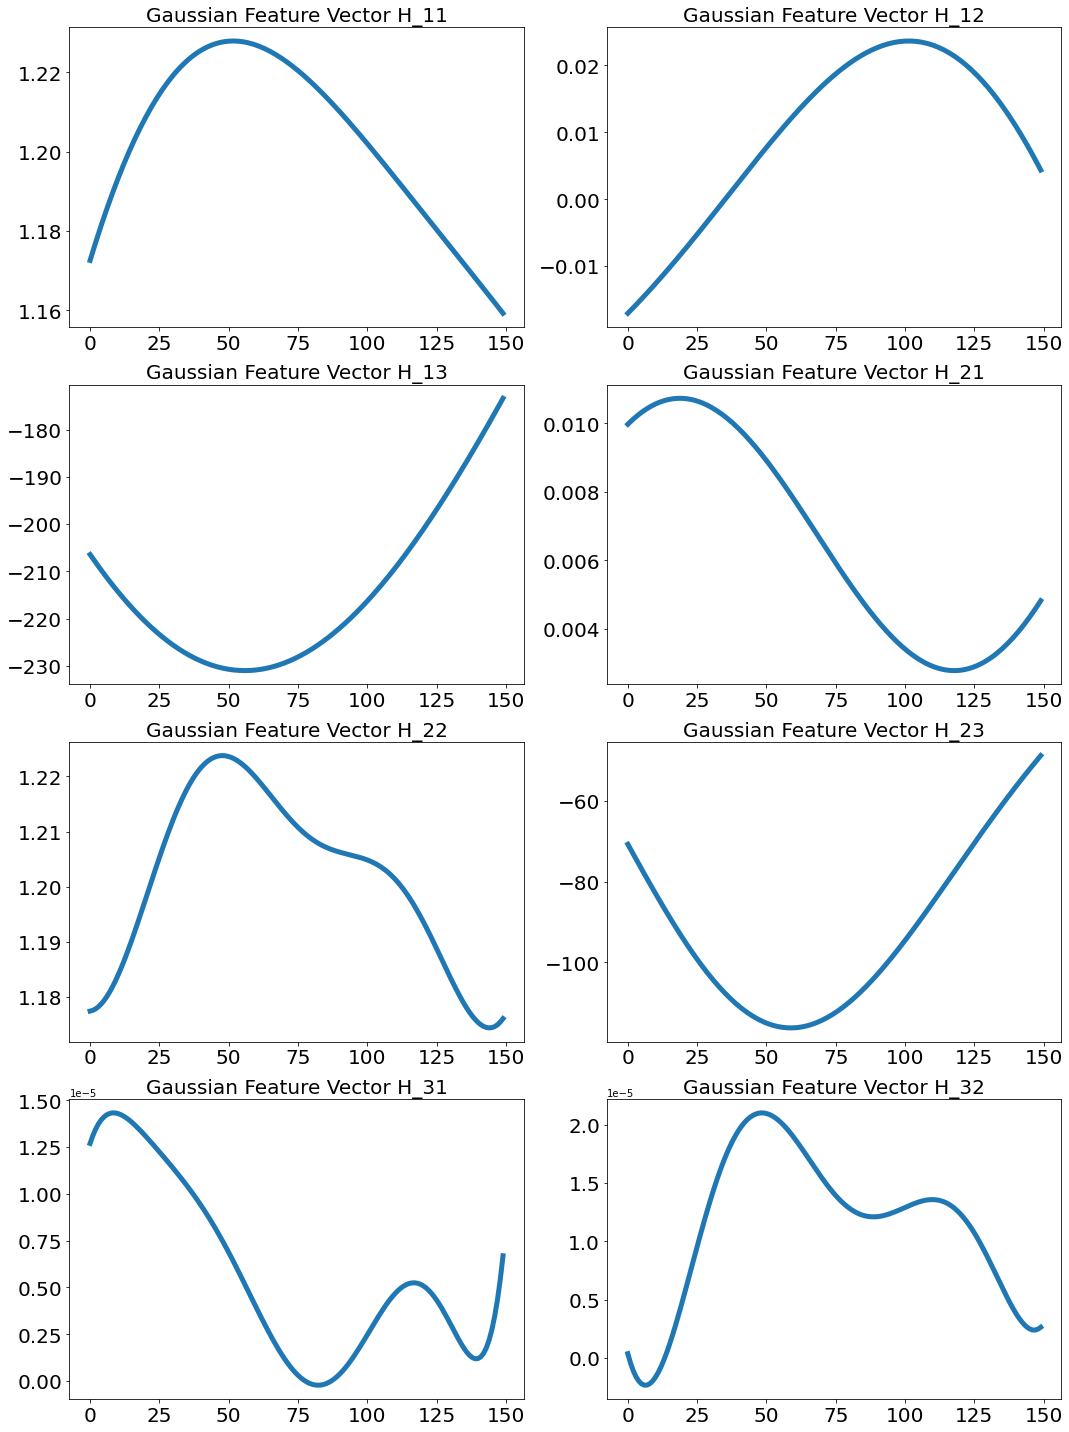

In [44]:
fig, axs = plt.subplots(4, 2, figsize=(15, 20))

# 分别绘制每个特征向量
axs[0, 0].plot(gaussian_feature_vector_H11, linewidth=5)
axs[0, 0].set_title('Gaussian Feature Vector H_11',fontsize=20)
axs[0, 0].tick_params(axis='both', labelsize=20)

axs[0, 1].plot(gaussian_feature_vector_H12, linewidth=5)
axs[0, 1].set_title('Gaussian Feature Vector H_12',fontsize=20)
axs[0, 1].tick_params(axis='both', labelsize=20)

axs[1, 0].plot(gaussian_feature_vector_H13, linewidth=5)
axs[1, 0].set_title('Gaussian Feature Vector H_13',fontsize=20)
axs[1, 0].tick_params(axis='both', labelsize=20)

axs[1, 1].plot(gaussian_feature_vector_H21, linewidth=5)
axs[1, 1].set_title('Gaussian Feature Vector H_21',fontsize=20)
axs[1, 1].tick_params(axis='both', labelsize=20)

axs[2, 0].plot(gaussian_feature_vector_H22, linewidth=5)
axs[2, 0].set_title('Gaussian Feature Vector H_22',fontsize=20)
axs[2, 0].tick_params(axis='both', labelsize=20)

axs[2, 1].plot(gaussian_feature_vector_H23, linewidth=5)
axs[2, 1].set_title('Gaussian Feature Vector H_23',fontsize=20)
axs[2, 1].tick_params(axis='both', labelsize=20)

axs[3, 0].plot(gaussian_feature_vector_H31, linewidth=5)
axs[3, 0].set_title('Gaussian Feature Vector H_31',fontsize=20)
axs[3, 0].tick_params(axis='both', labelsize=20)

axs[3, 1].plot(gaussian_feature_vector_H32, linewidth=5)
axs[3, 1].set_title('Gaussian Feature Vector H_32',fontsize=20)
axs[3, 1].tick_params(axis='both', labelsize=20)
# 调整每个subplot的布局
plt.tight_layout()
plt.show()

In [45]:
len(all_H32_entry[0])

150

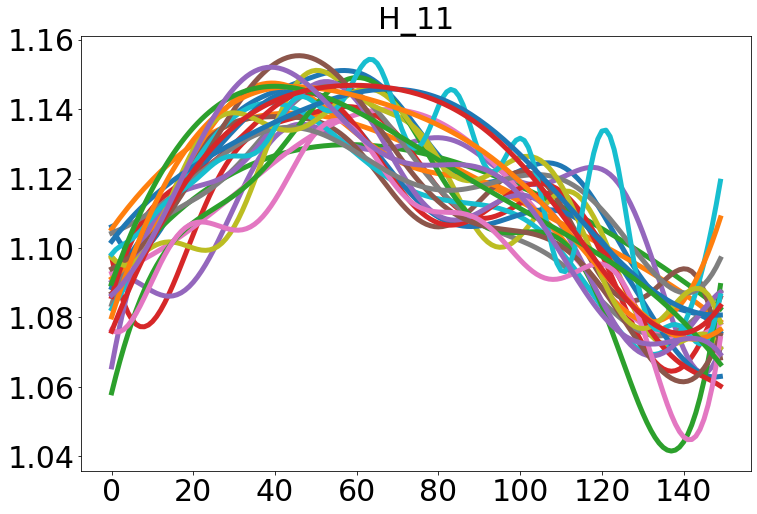

In [47]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import DotProduct, WhiteKernel
from sklearn.gaussian_process.kernels import ConstantKernel, RBF
plt.figure(figsize=(12,8))
j = 0
for i in range(len(all_H11_entry)):
    if i in [8,22]:
        continue
    X = range(len(all_H11_entry[i]))
    y = all_H11_entry[i]
    X = np.array(X).reshape(-1, 1)
    y = np.array(y).reshape(-1, 1)

    l = 0.1
    sigma_f = 2
    sigma_n = 0.01
    kernel = ConstantKernel(constant_value=sigma_f, constant_value_bounds=(1e-2, 1e2)) \
                * RBF(length_scale=l, length_scale_bounds=(1e-2, 1e2))
    gpr = GaussianProcessRegressor(kernel=kernel, alpha=sigma_n**2, n_restarts_optimizer=10).fit(X, y)
    y_pred = gpr.predict(X, return_std=True)[0]
    y_pred = y_pred.reshape([y_pred.shape[0]])
    j +=1
    plt.plot(range(len(all_H11_entry[0])),y_pred,linewidth=5.0,label='Participant%s Gaussian Regression Curve' %j)

#plt.xlabel("Time step", fontsize=20)
#plt.legend(loc='best')
plt.title("H_11", fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.show()
plt.show()

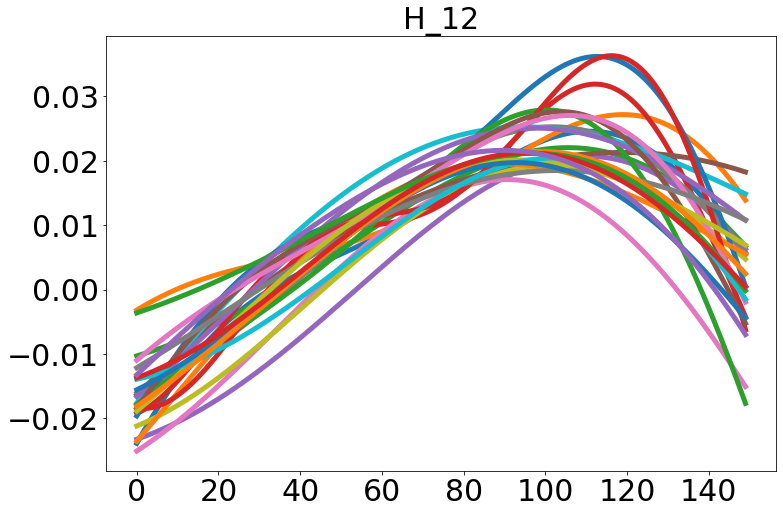

In [48]:
plt.figure(figsize=(12,8))
j=0
for i in range(len(all_H12_entry)):
    if i in [8,22]:
        continue
    X = range(len(all_H12_entry[i]))
    y = all_H12_entry[i]
    X = np.array(X).reshape(-1, 1)
    y = np.array(y).reshape(-1, 1)

    l = 0.1
    sigma_f = 2
    sigma_n = 0.01
    kernel = ConstantKernel(constant_value=sigma_f, constant_value_bounds=(1e-2, 1e2)) \
                * RBF(length_scale=l, length_scale_bounds=(1e-2, 1e2))
    gpr = GaussianProcessRegressor(kernel=kernel, alpha=sigma_n**2, n_restarts_optimizer=10).fit(X, y)
    y_pred = gpr.predict(X, return_std=True)[0]
    y_pred = y_pred.reshape([y_pred.shape[0]])
    j+=1
    plt.plot(range(len(all_H12_entry[0])),y_pred,linewidth=5.0,label='Participant%s Gaussian Regression Curve' %j)
#plt.xlabel("Time step", fontsize=20)
#plt.legend(loc='best')
plt.title("H_12", fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.show()
plt.show()

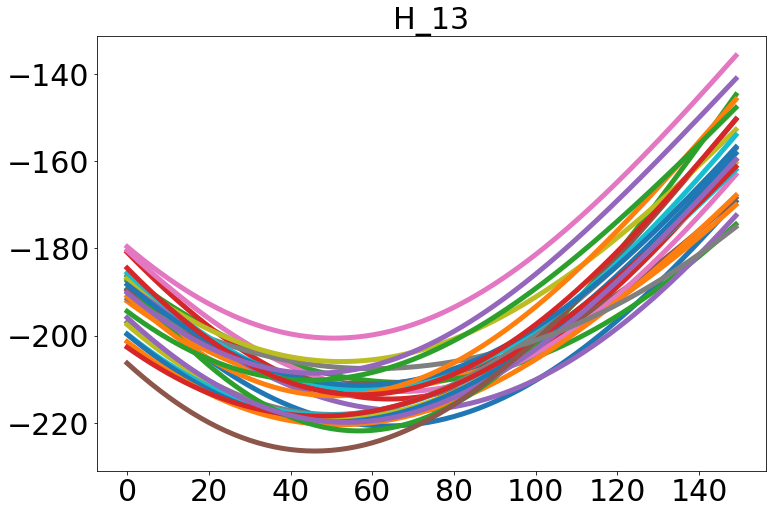

In [49]:
plt.figure(figsize=(12,8))
j=0
for i in range(len(all_H13_entry)):
    if i in [8,22]:
        continue
    X = range(len(all_H13_entry[i]))
    y = all_H13_entry[i]
    X = np.array(X).reshape(-1, 1)
    y = np.array(y).reshape(-1, 1)

    l = 0.1
    sigma_f = 2
    sigma_n = 10
    kernel = ConstantKernel(constant_value=sigma_f, constant_value_bounds=(1e-2, 1e2)) \
                * RBF(length_scale=l, length_scale_bounds=(1e-2, 1e2))
    gpr = GaussianProcessRegressor(kernel=kernel, alpha=sigma_n**2, n_restarts_optimizer=10).fit(X, y)
    y_pred = gpr.predict(X, return_std=True)[0]
    y_pred = y_pred.reshape([y_pred.shape[0]])
    j+=1
    plt.plot(range(len(all_H13_entry[0])),y_pred,linewidth=5.0,label='Participant%s Gaussian Regression Curve' %j)
#plt.xlabel("Time step", fontsize=20)
#plt.legend(loc='best')
plt.title("H_13", fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.show()
plt.show()

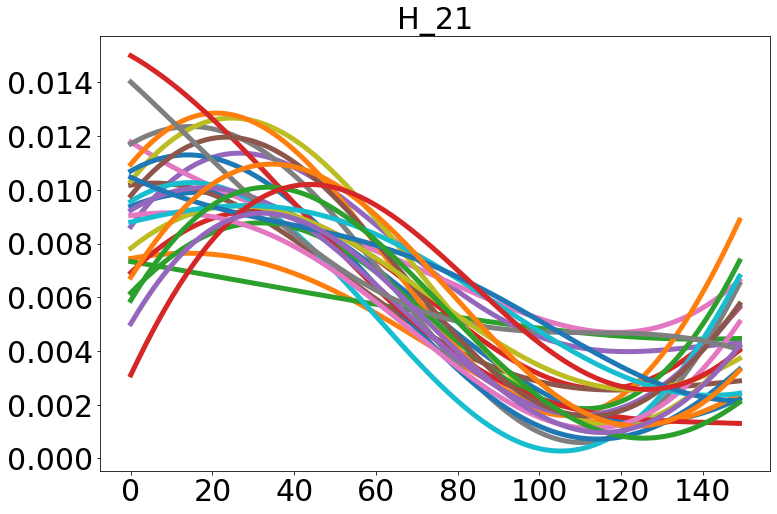

In [50]:
plt.figure(figsize=(12,8))
j=0
for i in range(len(all_H21_entry)):
    if i in [8,22]:
        continue
    X = range(len(all_H21_entry[i]))
    y = all_H21_entry[i]
    X = np.array(X).reshape(-1, 1)
    y = np.array(y).reshape(-1, 1)

    l = 0.1
    sigma_f = 2
    sigma_n = 0.01
    kernel = ConstantKernel(constant_value=sigma_f, constant_value_bounds=(1e-2, 1e2)) \
                * RBF(length_scale=l, length_scale_bounds=(1e-2, 1e2))
    gpr = GaussianProcessRegressor(kernel=kernel, alpha=sigma_n**2, n_restarts_optimizer=10).fit(X, y)
    y_pred = gpr.predict(X, return_std=True)[0]
    y_pred = y_pred.reshape([y_pred.shape[0]])
    j+=1
    plt.plot(range(len(all_H21_entry[0])),y_pred,linewidth=5.0,label='Participant%s Gaussian Regression Curve' %j)
#plt.xlabel("Time step", fontsize=20)
#plt.legend(loc='best')
plt.title("H_21", fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.show()
plt.show()

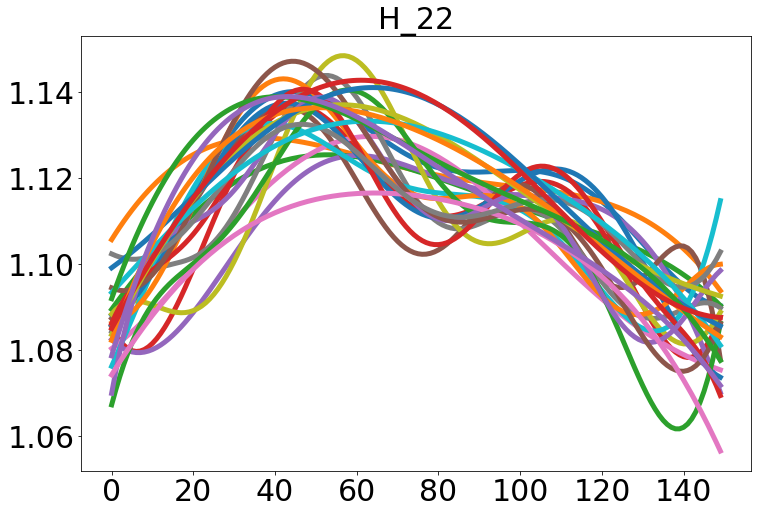

In [51]:
plt.figure(figsize=(12,8))
j=0
for i in range(len(all_H22_entry)):
    if i in [8,22]:
        continue
    X = range(len(all_H22_entry[i]))
    y = all_H22_entry[i]
    X = np.array(X).reshape(-1, 1)
    y = np.array(y).reshape(-1, 1)

    l = 0.1
    sigma_f = 2
    sigma_n = 0.01
    kernel = ConstantKernel(constant_value=sigma_f, constant_value_bounds=(1e-2, 1e2)) \
                * RBF(length_scale=l, length_scale_bounds=(1e-2, 1e2))
    gpr = GaussianProcessRegressor(kernel=kernel, alpha=sigma_n**2, n_restarts_optimizer=10).fit(X, y)
    y_pred = gpr.predict(X, return_std=True)[0]
    y_pred = y_pred.reshape([y_pred.shape[0]])
    j+=1
    plt.plot(range(len(all_H22_entry[0])),y_pred,linewidth=5.0,label='Participant%s Gaussian Regression Curve' %j)
#plt.xlabel("Time step", fontsize=20)
#plt.legend(loc='best')
plt.title("H_22", fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.show()
plt.show()

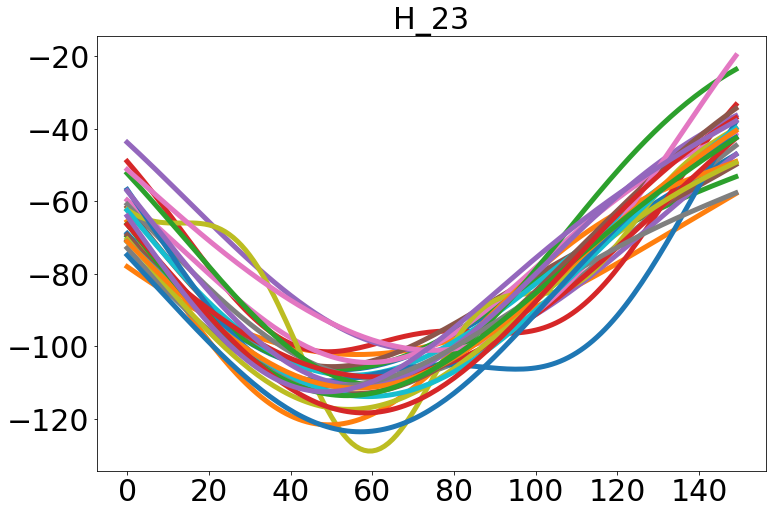

In [52]:
plt.figure(figsize=(12,8))
j=0
for i in range(len(all_H23_entry)):
    if i in [8,22]:
        continue
    X = range(len(all_H23_entry[i]))
    y = all_H23_entry[i]
    X = np.array(X).reshape(-1, 1)
    y = np.array(y).reshape(-1, 1)

    l = 0.1
    sigma_f = 2
    sigma_n = 10
    kernel = ConstantKernel(constant_value=sigma_f, constant_value_bounds=(1e-2, 1e2)) \
                * RBF(length_scale=l, length_scale_bounds=(1e-2, 1e2))
    gpr = GaussianProcessRegressor(kernel=kernel, alpha=sigma_n**2, n_restarts_optimizer=10).fit(X, y)
    y_pred = gpr.predict(X, return_std=True)[0]
    y_pred = y_pred.reshape([y_pred.shape[0]])
    j+=1
    plt.plot(range(len(all_H23_entry[0])),y_pred,linewidth=5.0,label='Participant%s Gaussian Regression Curve' %j)
#plt.xlabel("Time step", fontsize=20)
#plt.legend(loc='best')
plt.title("H_23", fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.show()
plt.show()

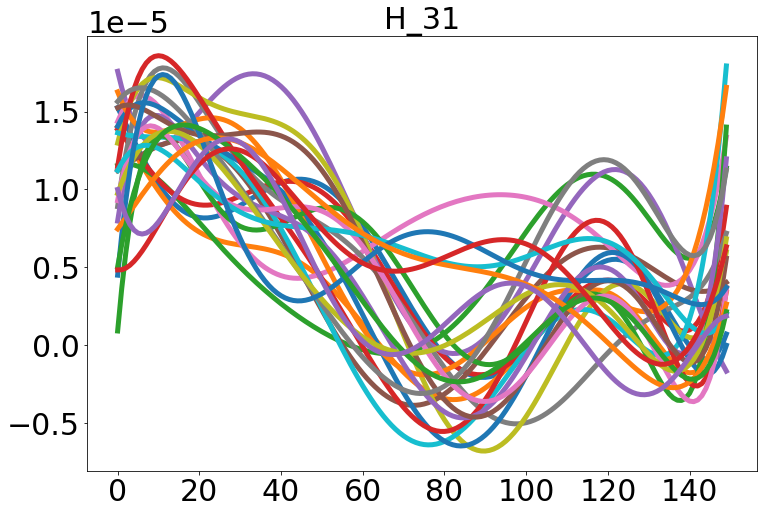

In [53]:
plt.figure(figsize=(12,8))
j=0
for i in range(len(all_H31_entry)):
    if i in [8,22]:
        continue
    X = range(len(all_H31_entry[i]))
    y = all_H31_entry[i]
    X = np.array(X).reshape(-1, 1)
    y = np.array(y).reshape(-1, 1)

    l = 0.1
    sigma_f = 2
    sigma_n = 0.00001
    kernel = ConstantKernel(constant_value=sigma_f, constant_value_bounds=(1e-2, 1e2)) \
                * RBF(length_scale=l, length_scale_bounds=(1e-2, 1e2))
    gpr = GaussianProcessRegressor(kernel=kernel, alpha=sigma_n**2, n_restarts_optimizer=10).fit(X, y)
    y_pred = gpr.predict(X, return_std=True)[0]
    y_pred = y_pred.reshape([y_pred.shape[0]])
    j+=1
    plt.plot(range(len(all_H31_entry[0])),y_pred,linewidth=5.0,label='Participant%s Gaussian Regression Curve' %j)
#plt.xlabel("Time step", fontsize=20)
#plt.legend(loc='best')
plt.gca().yaxis.offsetText.set_fontsize(30)
plt.title("H_31", fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.show()
plt.show()

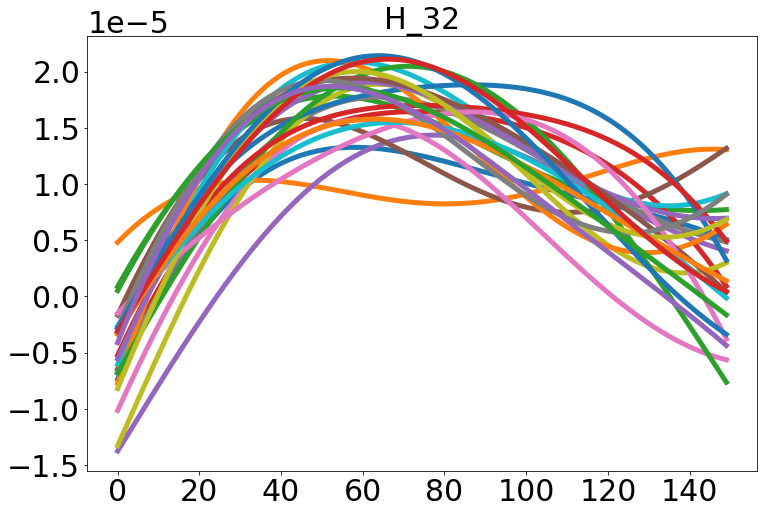

In [54]:
plt.figure(figsize=(12,8))
j=0
for i in range(len(all_H32_entry)):
    if i in [8,22]:
        continue
    X = range(len(all_H32_entry[i]))
    y = all_H32_entry[i]
    X = np.array(X).reshape(-1, 1)
    y = np.array(y).reshape(-1, 1)

    l = 0.1
    sigma_f = 2
    sigma_n = 0.01
    kernel = ConstantKernel(constant_value=sigma_f, constant_value_bounds=(1e-2, 1e2)) \
                * RBF(length_scale=l, length_scale_bounds=(1e-2, 1e2))
    gpr = GaussianProcessRegressor(kernel=kernel, alpha=sigma_n**2, n_restarts_optimizer=10).fit(X, y)
    y_pred = gpr.predict(X, return_std=True)[0]
    y_pred = y_pred.reshape([y_pred.shape[0]])
    j+=1
    plt.plot(range(len(all_H32_entry[0])),y_pred,linewidth=5.0,label='Participant%s Gaussian Regression Curve' %j)
#plt.xlabel("Time step", fontsize=20)
#plt.legend(loc='best')
plt.gca().yaxis.offsetText.set_fontsize(30)
plt.title("H_32", fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.show()
plt.show()